# Data preprocessing pipeline for used car price prediction
- Target: price

- Strategy: Complete-case(No missing values) based scaling and encoding

## Load libraries and import original data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# ignore warning message
import warnings
warnings.filterwarnings('ignore')

# load original data file
file_path = 'vehicles.csv'


if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Source Data Load Completed. Data Size: {df.shape}")
else:
    print("The file was not found, please check the path again.")
    print(f"The path you entered: {file_path}")


print(f"Original data size: {df.shape}")

Source Data Load Completed. Data Size: (426880, 26)
Original data size: (426880, 26)


## Step 1. Remove unnecessary features

In [27]:
# 1. Remove unnecessary or unreliable features for price prediction
columns_to_drop = [
    'id', 'url', 'image_url',                 # Unique identifiers and URLs
    'region', 'region_url', 'lat', 'long', 'state', # Location information
    'county',                                 # 100% missing value
    'size',                                    # 80% missing values & manually added by the scraper(not from the original website)
    'description'                           # Unstructured data with subjective views
]

df_step1 = df.drop(columns=columns_to_drop, errors='ignore')
print(f"Data size after removing columns: {df_step1.shape}")

Data size after removing columns: (426880, 15)


## Step 2. Remove all rows of missing values

In [28]:
# 2. Remove all records(rows) with at least one missing value
# (Keep only completely clean data without missing values)
df_step2 = df_step1.dropna()

print(f"Data size after removing rows with missing values {df_step2.shape}")

Data size after removing rows with missing values (61005, 15)


## Step 3. Outlier Detection

In [29]:
# 3. Outlier filtering using domain knowledge
# Exclude vehicles older than 20 years based on the posting date
# Convert posting_date to datetime format
df_step2['posting_date'] = pd.to_datetime(df_step2['posting_date'], utc=True)

# Extract posting year
posting_year = df_step2['posting_date'].dt.year

# Create filtering condition
condition_price = (
    (df_step2['price'] >= 1000) &
    (df_step2['price'] <= 1000000)
)

condition_odometer = (
    df_step2['odometer'] <= 300000
)

# Remove vehicles older than 20 years based on the posting year
condition_year = (
    df_step2['year'] >= (posting_year - 20)
)

# filtering
df_step3 = df_step2[
    condition_price &
    condition_odometer &
    condition_year
].copy()

print(f"Data size after outlier filtering: {df_step3.shape}")

Data size after outlier filtering: (54805, 15)


## Step 4. Create derived feature: vehicle_age

In [30]:
# 4. Create Vehicle Age feature and remove year column
# Calculate vehicle age using posting_date

# Time-series data processing

df_step3['posting_date'] = pd.to_datetime(df_step3['posting_date'], utc=True)

df_step3['vehicle_age'] = df_step3['posting_date'].dt.year - df_step3['year']

# Remove posting_date and year due to multicollinearity (VIF) with vehicle_age
df_step4 = df_step3.drop(columns=['posting_date', 'year'])

print("Derived feature 'vehicle_age' created successfully based on posting date")
display(df_step4[['vehicle_age', 'price', 'odometer']].head(3))

Derived feature 'vehicle_age' created successfully based on posting date


,vehicle_age,price,odometer
32,9.0,27990,68696.0
33,5.0,34590,29499.0
35,5.0,29990,17302.0


## Step 5. VIN preprocessing

In [31]:
# 5. VIN preprocessing

# Convert all letters to uppercase and check whether VIN consists of 17 characters
# containing only uppercase letters and numbers (excluding I, O, and Q)
df_step4['VIN'] = (
    df_step4['VIN']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Create VIN validation condition
condition_vin = df_step4['VIN'].str.fullmatch(
    r'[A-HJ-NPR-Z0-9]{17}',
    na=False
)

# Keep only rows satisfying the VIN condition
df_step5 = df_step4[condition_vin].copy()

print(f"Data size after VIN filtering: {df_step5.shape}")

Data size after VIN filtering: (54690, 14)


## Step 6. Clean model strings

In [32]:
# 6. Clean model feature strings (resolve inconsistencies such as f-150 and F150)
# Convert all strings to lowercase and remove all non-alphanumeric characters
# (e.g., spaces, hyphens) using regular expressions

df_step5['model_clean'] = df_step5['model'].astype(str).str.lower().apply(lambda x: re.sub(r'[^a-z0-9]', '', x))

# Compare the number of unique values before and after cleaning
original_unique = df_step5['model'].nunique()
clean_unique = df_step5['model_clean'].nunique()

# Replace the original model column with the cleaned version
df_step5['model'] = df_step5['model_clean']
df_step5.drop(columns=['model_clean'], inplace=True)

print(f"Model string cleaning completed.\nNumber of unique model types: {original_unique:,} → {clean_unique:,}")

Model string cleaning completed.
Number of unique model types: 5,780 → 5,407


## Random sampling of 10,000 rows (before feature creation using VIN)

In [33]:
df_sample = df_step5.sample(n=10000, random_state=42)

df_sample.to_csv(
    'preprocessed_used_cars_sample_10000.csv',
    index=False,
    encoding='utf-8-sig'
)

#### From this point onward, we use the vehicles_msrp.csv file, which includes the 'estimate_msrp' feature and has been cleaned by removing missing values and outliers from the 10,000 sampled data.

## Load data after VIN feature creation

In [34]:
# Load data file
new_file_path = 'vehicles_msrp.csv'


if os.path.exists(new_file_path):
    df_new = pd.read_csv(new_file_path)
    print(f"Data loaded successfully. Data size: {df_new.shape}")
else:
    print("The file was not found, please check the path again.")
    print(f"The path you entered: {new_file_path}")


print(f"Data size: {df_new.shape}")

Data loaded successfully. Data size: (7192, 15)
Data size: (7192, 15)


## Step 7. Encode categorical variables

In [35]:
# 7. Categorical variables encoding (Label & One-Hot Encoding)

# [1] Label Encoding for ordinal feature: condition
cond_map = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5}
df_new['condition'] = df_new['condition'].map(cond_map)

# [2] Extract numeric values from the cylinders feature
# e.g., "8 cylinders" -> 8
extracted_cylinders = df_new['cylinders'].astype(str).str.extract(r'(\d+)')[0]
# Preserve values without numeric information
# (e.g., electric vehicles or rotary engines originally labeled as 'other')
df_new['cylinders'] = extracted_cylinders.fillna('other')

# [3] Frequency-based grouping and dimensionality reduction
# Reduce excessive feature expansion caused by one-hot encoding
# Keep categories that either:
# - account for at least 1% of the total distribution, or
# - are included until the cumulative distribution reaches 85%
def smart_grouping(series, min_freq=0.01, max_cumulative=0.85):
    # Calculate and sort category distribution percentages in descending order
    frequencies = series.value_counts(normalize=True)

    valid_categories = []
    cumulative_sum = 0

    for cat, freq in frequencies.items():
        # When occupancy is too low (e.g., less than 1%)
        if freq < min_freq:
            break

        valid_categories.append(cat)
        cumulative_sum += freq

        # Stop preserving additional categories once cumulative coverage exceeds 85%
        if cumulative_sum >= max_cumulative:
            break

    # Convert all remaining low-frequency categories to 'other'
    return series.apply(lambda x: x if x in valid_categories else 'other')

# Apply frequency-based grouping to high-cardinality features
grouping_cols = ['manufacturer', 'paint_color', 'type']

for col in grouping_cols:
    df_new[col] = smart_grouping(df_new[col])

    # Check the final proportion of the 'other' category
    other_ratio = (df_new[col] == 'other').mean() * 100
    print(f"[{col}] Result of controlling the proportion of 'other' categories in each feature: {other_ratio:.1f}%")

# [4] One-Hot Encoding for nominal categorical variables
cols_to_ohe = ['cylinders', 'manufacturer', 'fuel', 'transmission', 'type', 'title_status', 'drive', 'paint_color']
df_encoded = pd.get_dummies(df_new, columns=cols_to_ohe, drop_first=True, dtype=int)

# Temporarily separate VIN since it is not used for model training
# (kept for later traceability)
df_final = df_encoded.drop(columns=['VIN'], errors='ignore')

print(f"Initial encoding before train/test split completed.\nCurrent number of features: {df_final.shape[1]}")


[manufacturer] Result of controlling the proportion of 'other' categories in each feature: 13.8%
[paint_color] Result of controlling the proportion of 'other' categories in each feature: 8.1%
[type] Result of controlling the proportion of 'other' categories in each feature: 18.9%
Initial encoding before train/test split completed.
Current number of features: 52


## Step 8. Scale numerical features

In [36]:
# 8-1. Split the dataset to prevent data leakage during target encoding
# Separate X(features) and y(target variable)
X = df_final.drop(columns=['price'])
y = df_final['price']

# Log transformation (log1p) to reduce right-skewness of the target variable (Price)
# After prediction, restore to the original dollar scale using np.expm1()
y_log = np.log1p(y)

print(f"X: {X.shape}")
print(f"y_log transformation completed — Mean: {y_log.mean():.2f}, Std: {y_log.std():.2f}")

X: (7192, 51)
y_log transformation completed — Mean: 9.71, Std: 0.71


In [37]:
# 8-2. Train / Test split
# Modify only this cell when experimenting with different split ratios (y_log is shared from the cell above)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Train / Test split completed.")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train_log: {y_train_log.shape}, y_test_log: {y_test_log.shape}")

Train / Test split completed.
X_train: (5753, 51), X_test: (1439, 51)
y_train_log: (5753,), y_test_log: (1439,)


## Step 9. Target encoding
Target Encoding converts categorical values into the mean of the target variable.
Used to reduce the high-dimensional feature expansion caused by one-hot encoding, especially for high-cardinality features such as vehicle models.
Mean values are learned from the training set and then mapped to the test set using the same category-to-mean relationship.

In [38]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\ds_virtual\venv1\Scripts\python.exe -m pip install --upgrade pip' command.


In [39]:
# 9. Apply Target Encoding using category_encoders to prevent overfitting and data leakage
import category_encoders as ce

# 1. Create a TargetEncoder object
# smoothing=10:
# For categories with a small number of samples, partially reflect the global mean to reduce overfitting
target_encoder = ce.TargetEncoder(cols=['model'], smoothing=10)

# 2. Apply fit_transform to X_train to learn target statistics from the training labels and transform the data
X_train['model_encoded'] = target_encoder.fit_transform(X_train['model'], y_train_log)

# 3. Apply transform only to X_test to prevent data leakage
X_test['model_encoded'] = target_encoder.transform(X_test['model'])

# Remove the original text columns after encoding
X_train.drop(columns=['model'], inplace=True)
X_test.drop(columns=['model'], inplace=True)

print("Target Encoding with smoothing completed.")

Target Encoding with smoothing completed.


## Step 10. Numerical feature scaling

In [40]:
# Save a raw copy of X_train before applying StandardScaler
# Because StandardScaler transforms X_train in-place,
# this backup (X_train_raw) is kept as a reference for visualizations
# that require pre-scaling values (e.g., Before/After comparison of estimate_msrp).
X_train_raw = X_train.copy()

print(f"X_train_raw saved: {X_train_raw.shape}")
print(f"estimate_msrp original stats — Mean: {X_train_raw['estimate_msrp'].mean():.0f}, Std: {X_train_raw['estimate_msrp'].std():.0f}")

X_train_raw saved: (5753, 51)
estimate_msrp original stats — Mean: 36833, Std: 15725


In [41]:
# 10. Apply StandardScaler to numerical features

# estimate_msrp: right-skewed distribution — apply log1p transformation first
# to bring it closer to a normal distribution before scaling
X_train['estimate_msrp'] = np.log1p(X_train['estimate_msrp'])
X_test['estimate_msrp'] = np.log1p(X_test['estimate_msrp'])

# Save the post-log1p, pre-scaling state for visualization (EDA sections 5 & 6)
X_train_log1p = X_train.copy()

scaler = StandardScaler()

# Select features for scaling
num_cols = ['odometer', 'vehicle_age', 'model_encoded', 'estimate_msrp']

# Apply fit_transform to X_train (learn scaling parameters and transform)
# Apply transform only to X_test to prevent data leakage
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Entire preprocessing pipeline completed successfully. Ready for modeling.")
print("\n[Final X_train data preview]")
display(X_train.head(3))

Entire preprocessing pipeline completed successfully. Ready for modeling.

[Final X_train data preview]


,condition,odometer,vehicle_age,estimate_msrp,cylinders_12,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,...,title_status_salvage,drive_fwd,drive_rwd,paint_color_blue,paint_color_grey,paint_color_other,paint_color_red,paint_color_silver,paint_color_white,model_encoded
6256,3,0.441272,0.078763,1.707143,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.024342
4668,3,-1.069441,-1.549501,0.480729,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.303513
940,3,0.789042,1.474417,0.461511,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,-0.641015


# EDA on preprocessed data (post-validation visualization)

In [42]:
# Set visualization theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['axes.unicode_minus'] = False

# Temporarily merge X_train and y_train_log for visualization and analysis
df_eda = X_train.copy()
df_eda['price_log'] = y_train_log

print("Integrated dataframe for EDA is ready")

Integrated dataframe for EDA is ready


## 1. Check the distribution of the log-transformed target variable

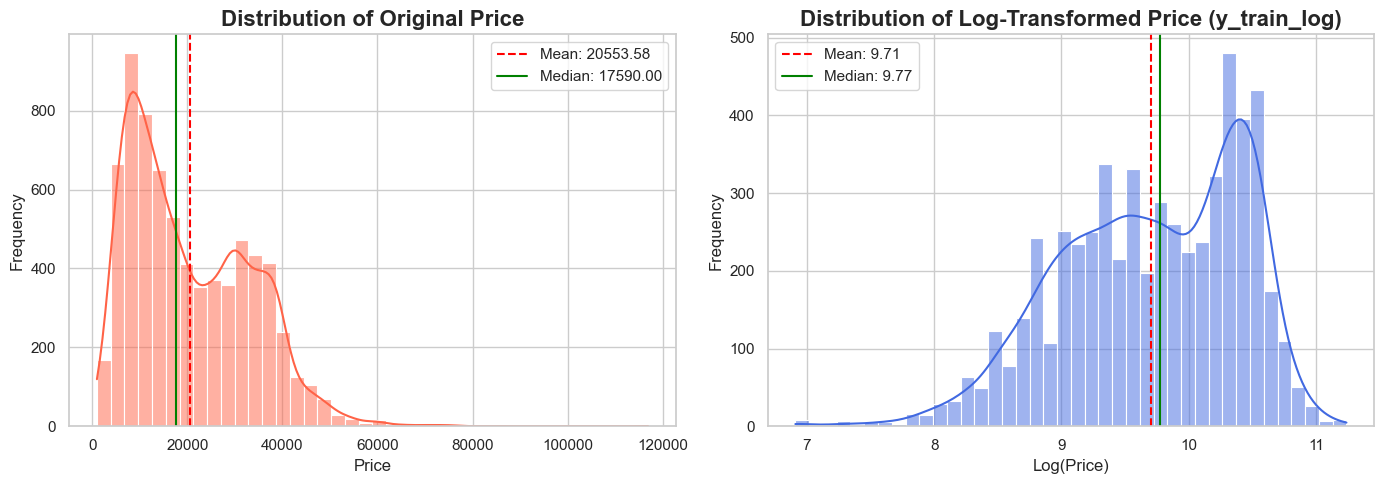

In [43]:
# 1. Validate the target variable distribution
plt.figure(figsize=(14, 5))

# Before log transformation
plt.subplot(1, 2, 1)

sns.histplot(df_new['price'], bins=40, kde=True, color='tomato')

plt.title("Distribution of Original Price", fontsize=16, fontweight='bold')
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display mean and median values
plt.axvline(df_new['price'].mean(), color='red', linestyle='--', label=f"Mean: {df_new['price'].mean():.2f}")
plt.axvline(df_new['price'].median(), color='green', linestyle='-', label=f"Median: {df_new['price'].median():.2f}")
plt.legend()

# after log transformation
plt.subplot(1, 2, 2)

sns.histplot(df_eda['price_log'], bins=40, kde=True, color='royalblue')
plt.title("Distribution of Log-Transformed Price (y_train_log)", fontsize=16, fontweight='bold')
plt.xlabel("Log(Price)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display mean and median values
plt.axvline(df_eda['price_log'].mean(), color='red', linestyle='--', label=f"Mean: {df_eda['price_log'].mean():.2f}")
plt.axvline(df_eda['price_log'].median(), color='green', linestyle='-', label=f"Median: {df_eda['price_log'].median():.2f}")

plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation: Distribution of Log-Transformed Price (y_train_log)

**Motivation (expected effect)**  
A typical used-car price distribution is concentrated in the mid-price range, with a long right tail caused by a small number of high-priced vehicles.  
A log transformation was applied to address this and make the distribution more stable and to improve model training performance.

---

**Result interpretation**  
The strong right skew of the original distribution has been greatly reduced.

The mean (9.71) and median (9.77) are very close to each other.  
→ The transformed distribution is now close to symmetric, indicating the data is no longer heavily skewed.  
→ This suggests the log transformation was effective at reducing skewness.

The two peaks suggest the data may be split to some degree into a lower-priced group and a higher-priced group.

## 2. Verify the results of StandardScaler

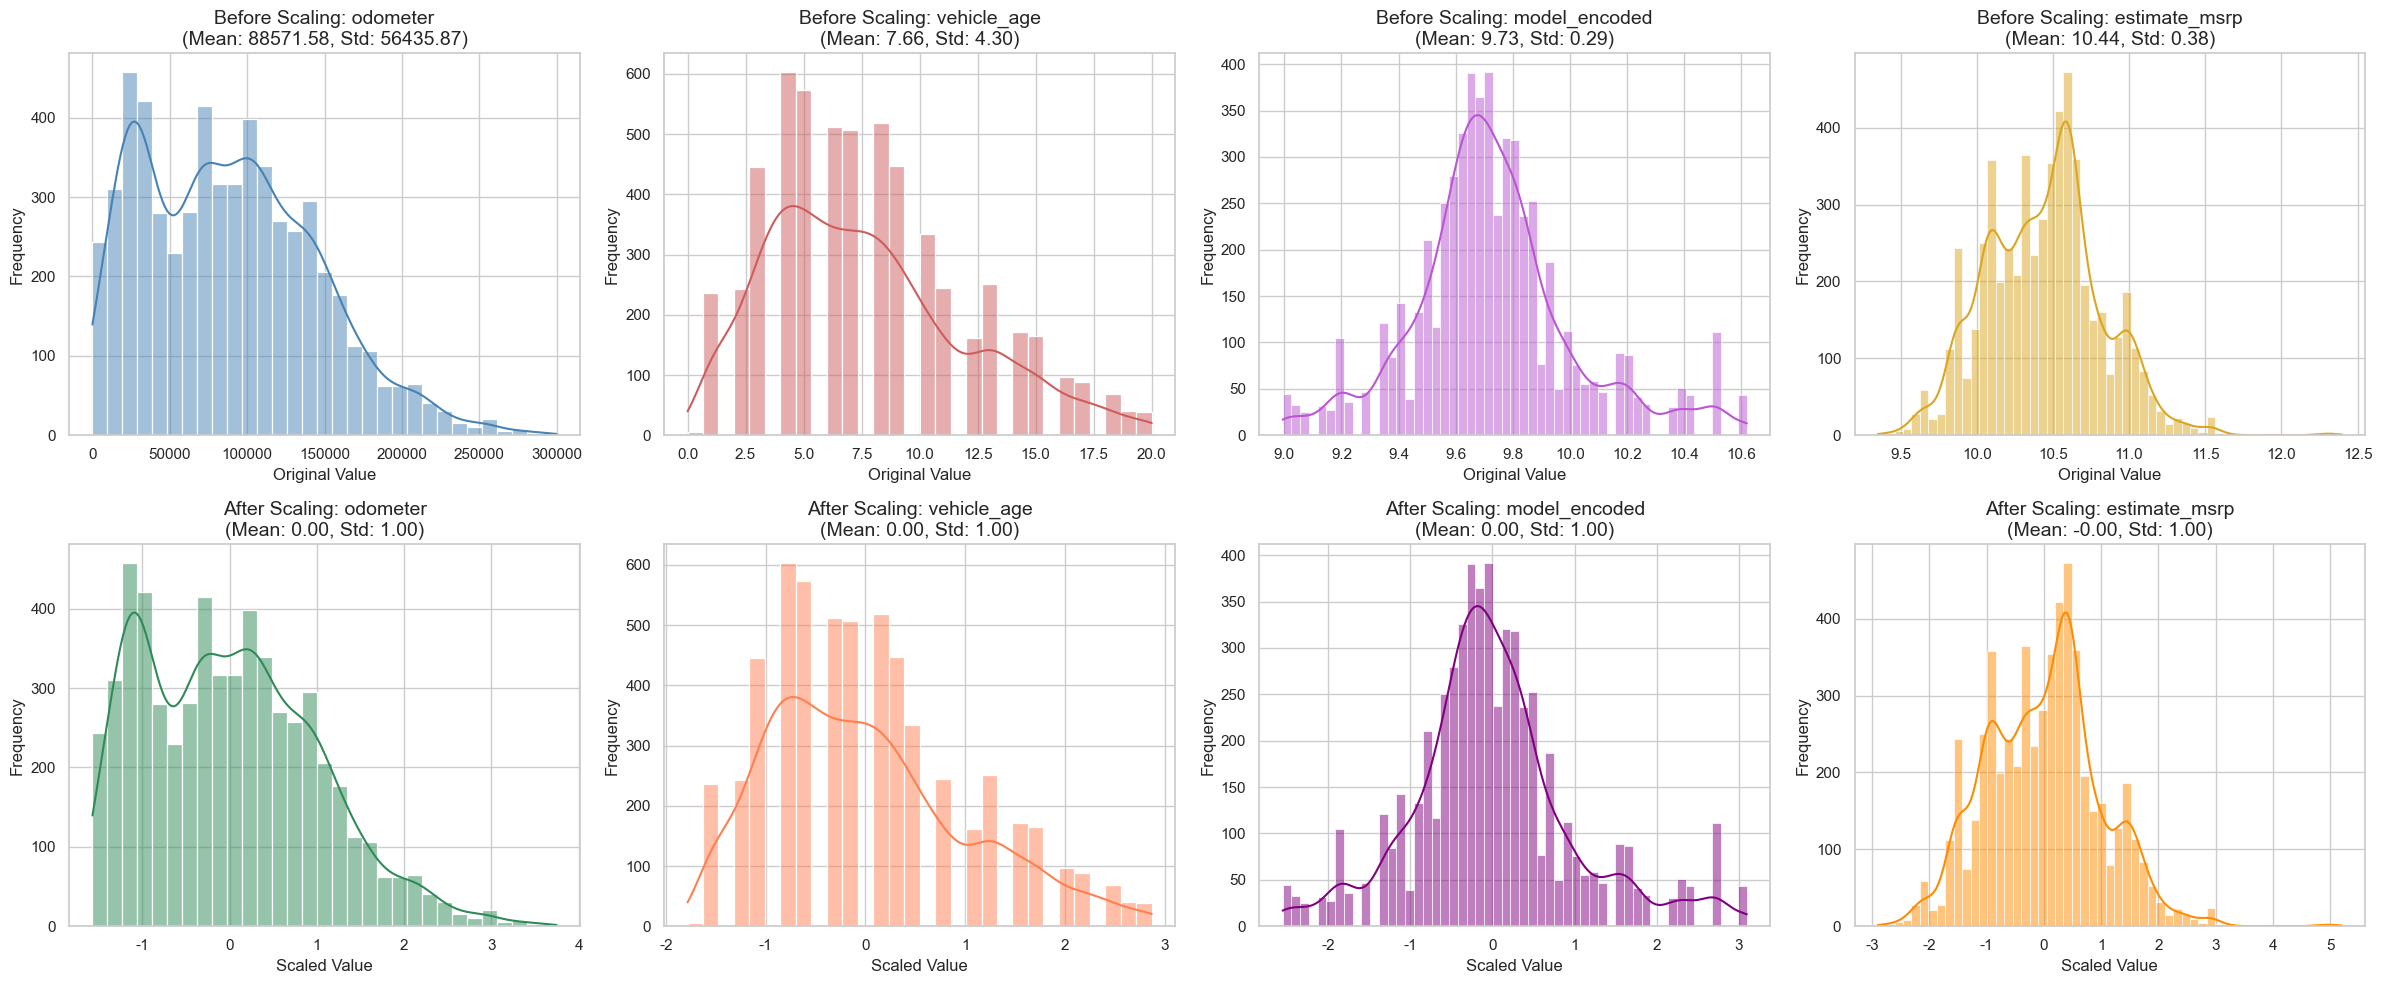

In [44]:
# 2. Validate the distribution of scaled numerical features
# -> Check whether the values are properly centered around mean 0 and standard deviation 1

original_cols = ['odometer', 'vehicle_age', 'model_encoded', 'estimate_msrp']
scaled_cols = ['odometer', 'vehicle_age', 'model_encoded', 'estimate_msrp']

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

colors_before = ['steelblue', 'indianred', 'mediumorchid', 'goldenrod']
colors_after = ['seagreen', 'coral', 'purple', 'darkorange']

# Before Scaling
for i, col in enumerate(original_cols):

    sns.histplot(X_train_log1p[col], kde=True, ax=axes[0, i], color=colors_before[i])

    axes[0, i].set_title(
        f"Before Scaling: {col}\n(Mean: {X_train_log1p[col].mean():.2f}, Std: {X_train_log1p[col].std():.2f})",
        fontsize=14
    )

    axes[0, i].set_xlabel("Original Value")
    axes[0, i].set_ylabel("Frequency")

# After Scaling
for i, col in enumerate(scaled_cols):

    sns.histplot(X_train[col], kde=True, ax=axes[1, i], color=colors_after[i])

    axes[1, i].set_title(
        f"After Scaling: {col}\n(Mean: {X_train[col].mean():.2f}, Std: {X_train[col].std():.2f})",
        fontsize=14
    )

    axes[1, i].set_xlabel("Scaled Value")
    axes[1, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Interpretation: Scaled odometer, vehicle_age, model_encoded, estimate_msrp

**Motivation (expected effect)**  
Each feature has a different value range, which can cause certain features to dominate or slow down training, so Standard Scaling was applied.  

The LLM-estimated vehicle MSRP shows a right-skewed distribution due to a small number of high-priced vehicles.  

Since StandardScaler alone cannot change the shape of the distribution, `np.log1p` is applied first to bring it closer to a normal distribution before scaling.

---

**Result interpretation**  
As intended, every distribution shows a mean close to 0 and a standard deviation close to 1 after the transformation.

**- odometer**  
A small number of high-mileage vehicles (whether they are true outliers needs further checking) still produces a long right tail, but the feature has been stably standardized.

**- vehicle_age**  
Because vehicle age is an integer (discrete) variable, there are gaps between values. It shows a right-skewed distribution indicating that some older vehicles are included.

**- model_encoded**  
Model_encoded is the variable produced by Target Encoding. Because each model was converted into a continuous, mean-price-based value, the distribution of model_encoded appears relatively closer to a normal distribution compared to the other scaled features.

**- estimate_msrp**  
Two peaks are observed around the median, suggesting the data may be split to some degree into a lower-priced and a higher-priced vehicle group.

## 3. Visualize relationships between key features and log-transformed price using regression scatter plots

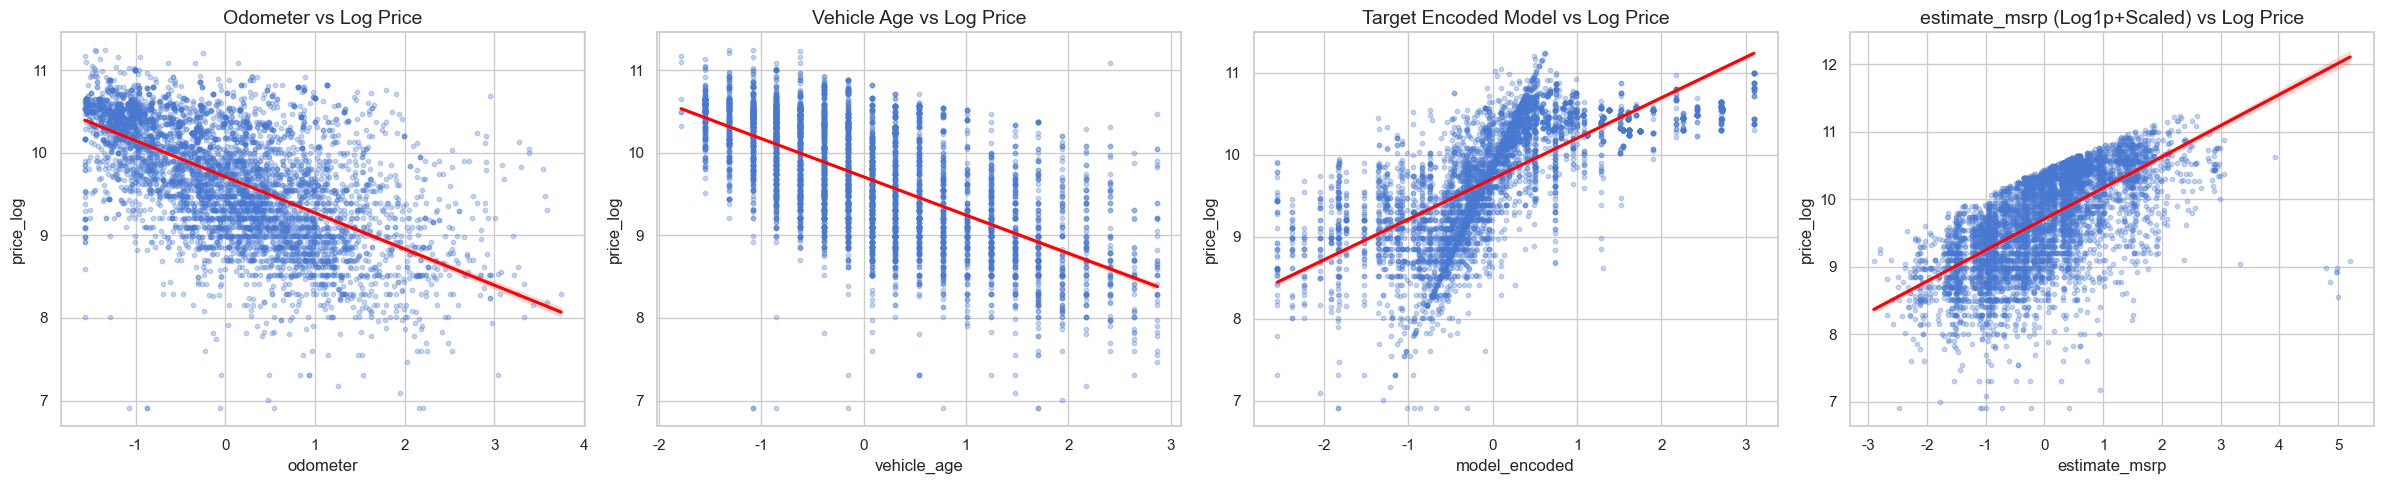

In [45]:
# 3. Relationship between major numerical/encoded features and log-transformed price

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 3-1. Odometer vs Price (expected negative correlation)
sns.regplot(data=df_eda, x='odometer', y='price_log', ax=axes[0],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[0].set_title("Odometer vs Log Price", fontsize=14)

# 3-2. Vehicle Age vs Price (expected negative correlation)
sns.regplot(data=df_eda, x='vehicle_age', y='price_log', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[1].set_title("Vehicle Age vs Log Price", fontsize=14)

# 3-3. Model encoded value vs Price (expected strong positive correlation)
sns.regplot(data=df_eda, x='model_encoded', y='price_log', ax=axes[2],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[2].set_title("Target Encoded Model vs Log Price", fontsize=14)

# 3-4. Estimated MSRP vs Price (expected positive correlation)
sns.regplot(data=df_eda, x='estimate_msrp', y='price_log', ax=axes[3],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[3].set_title("estimate_msrp (Log1p+Scaled) vs Log Price", fontsize=14)

plt.tight_layout()
plt.show()

#### Interpretation: Scatter plots

**Motivation (expected effect)**  
These plots check the relationship between each feature and price, whether a linear relationship exists, and whether the feature is meaningful for a regression model. The regression line (red) lets us visually confirm whether the correlation is positive (+) or negative (–) and how strong it is.

---

**Result interpretation**

**- odometer vs log price**  
The regression line shows a negative correlation → it follows the realistic pattern that price falls as mileage increases. It is not a perfect straight line because price is also affected by factors such as brand and model year.

**- vehicle_age vs log price**  
The regression line shows a negative correlation → it follows the realistic pattern that price falls as the vehicle gets older. Because vehicle_age is an integer (discrete) variable, the points appear in vertical bands.

**- target encoded model vs log price**  
The regression line shows a positive correlation. Because the model variable was target-encoded based on price, it is positively correlated with price.  

**However**, since the regression line is the single best-fit line across all points, it may look different from the central cluster of points, which appears to rise steeply.  

**- estimate_msrp vs log price**  
The log transformation spreads the x-axis distribution more evenly, making the positive correlation (+) more clearly visible.  
This confirms visually that the LLM-estimated MSRP based on vehicle specifications has a meaningful relationship with the actual used car price.

## 4. Heatmap of the most important feature correlations for modeling - Top 15 features

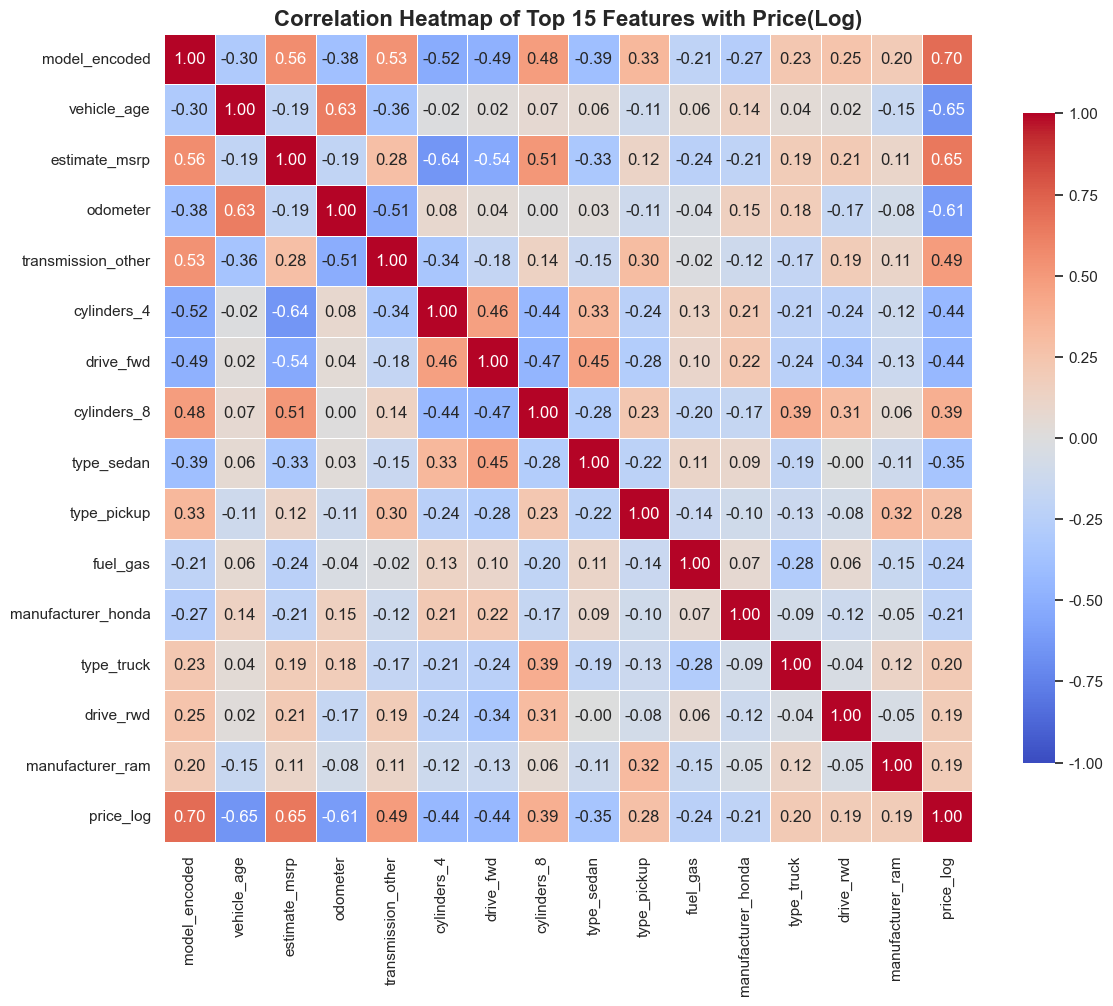

In [46]:
# 4. Extract the Top 15 features most correlated with the target variable (price_log) and visualize them using a heatmap

# Calculate correlations with the target variable and sort them by absolute correlation values in descending order
correlations = df_eda.corr()['price_log'].abs().sort_values(ascending=False)

# Select the Top 15 features excluding the target variable itself (price_log)
top_15_features = correlations.index[1:16]

# Create a correlation matrix using the Top 15 features and the target variable
top_corr_matrix = df_eda[top_15_features.tolist() + ['price_log']].corr()

plt.figure(figsize=(12, 10))
# Visualization
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Top 15 Features with Price(Log)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()